In [1]:
from mpramnist.DNASynBench import SimpleMotifDataset
from mpramnist.DNASynBench import LitModel_DNASyn_REG, LitModel_DNASyn_CLS

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

from mpramnist import transforms as t

import torch.nn as nn
import torch.utils.data as data

import lightning.pytorch as L

BATCH_SIZE = 128
NUM_WORKERS = 8

In [2]:
# Define set of transforms
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
val_test_transform = t.Compose([t.Seq2Tensor(),])

# Generating task 1 (simple classification)
dataset = SimpleMotifDataset()
dataset.generate(motif='AGTCGACT',
    length=500,
    n_seqs=20000,
    train_size=0.7,
    random_state=42)

train_dataset = dataset.get_split("train", transform=train_transform)
val_dataset = dataset.get_split("val", transform=val_test_transform)
test_dataset = dataset.get_split("test", transform=val_test_transform)

# Encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = train_dataset.n_classes   # = 1 in case of regression task

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:02<00:00, 7904.29it/s]


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.
/home/vastre34/miniconda3/envs/mpramnist/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated,

Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…


----------------------------------------------------------------------------------------------------
| Epoch: 0 | Val AUROC: 0.5257026553153992 
| Val Precision: 0.5334309935569763 | Val Recall: 0.5239480137825012 | Val F1: 0.523735523223877 
----------------------------------------------------------------------------------------------------



Validation: |                                                                                     | 0/? [00:00…

...

`Trainer.fit` stopped: `max_epochs=5` reached.



----------------------------------------------------------------------------------------------------
| Epoch: 4 | Val AUROC: 0.9968792200088501 
| Val Precision: 0.970089316368103 | Val Recall: 0.9828519821166992 | Val F1: 0.976309597492218 
----------------------------------------------------------------------------------------------------



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |                                                                                        | 0/? [00:00…


----------------------------------------------------------------------------------------------------
| Epoch: 5 | Test AUROC: 0.9991731643676758 
| Test Precision: 0.983269453048706 | Test Recall: 0.988001823425293 | Test F1: 0.985613226890564 
----------------------------------------------------------------------------------------------------



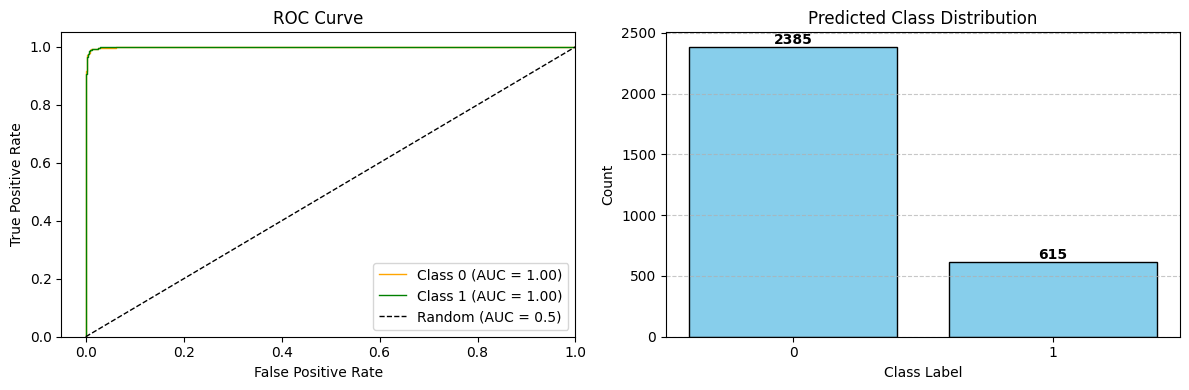

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1             0.985613226890564
        test_loss           0.11956005543470383
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.11956005543470383, 'test_f1': 0.985613226890564}]

In [3]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_DNASyn_CLS(   # = LitModel_DNASyn_REG in case of regression task
    model=model,
    loss=nn.CrossEntropyLoss(),   # = nn.MSELoss() in case of regression task
    weight_decay=1e-4,
    lr=1e-4,
    n_classes=out_channels,
    print_each=1
)
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=5,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)